# Inference Check

In [1]:
import os

os.chdir("..")

## Inference Visualization

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from PIL import Image

from pathlib import Path


def plot_inference(
    images_root: Path, inference: pd.DataFrame, min_confidence: float
) -> None:
    im_name = inference.iloc[0]["filename"]
    im_path = list(images_root.rglob(im_name))[0]
    img = Image.open(str(im_path))
    img = np.array(img)

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    for _, pred in inference.iterrows():
        if pred["confidence"] < min_confidence:
            continue

        xmin, ymin, xmax, ymax = pred["xmin"], pred["ymin"], pred["xmax"], pred["ymax"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        confidence = pred["confidence"]
        ax.add_patch(rect)
        ax.text(
            xmin,
            ymin,
            f"{confidence:.2f}",
            color="white",
            bbox=dict(facecolor="red", alpha=0.5),
        )

    plt.axis("off")
    plt.show()

Get the data paths:

In [5]:
from pathlib import Path

INFERENCES = list(Path("output_predictions").glob("*.csv"))
IMAGES_ROOT = Path("../data_det_public/data_det_public")

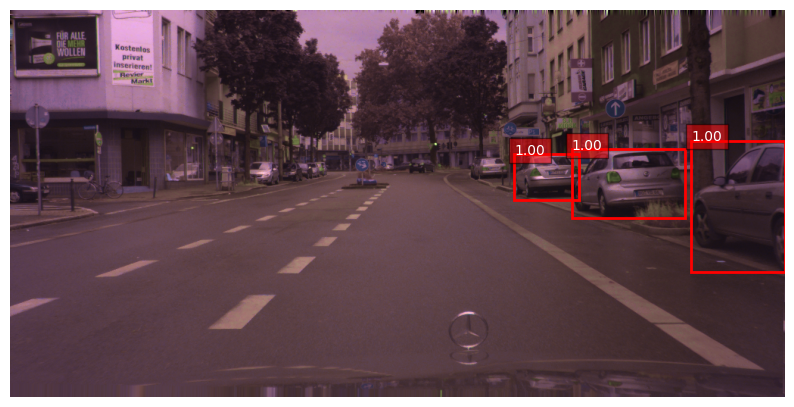

In [13]:
SAMPLE_IDX = 28
CONFIDENCE = 0.6

df = pd.read_csv(str(INFERENCES[SAMPLE_IDX]))
plot_inference(IMAGES_ROOT, df, CONFIDENCE)